<a href="https://colab.research.google.com/github/claramanolache/ML_Intro/blob/main/Week_3_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 3: Practice Notebook

**You do not need to submit this Notebook.** It is for practice only.

## Introduction to the Dataset

The MNIST dataset is a classic benchmark in machine learning, widely used for training and evaluating algorithms in handwritten digit recognition. It contains 70,000 grayscale images of digits from 0 to 9, each sized 28 by 28 pixels, with 60,000 images designated for training and 10,000 for testing. MNIST contains a diverse set of writing styles from both Census Bureau employees and high school students, making it a great starting point for using images with simple machine learning models.

### Goal
We will build a classifier that seeks to identify which digit each image corresponds.

## Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn import dummy
from sklearn import linear_model
from sklearn import metrics
from sklearn import model_selection

The following variable will be used to set a random seed for certain processes. Using a seed makes random processes deterministic, meaning this notebook will do things like split data the same way on each run. You are free to change this value to explore how the notebook runs differently.

In [ ]:
seed = 42

In this Practice Notebook, we will explore a classification problem - first as a set of two classes to predict, and then as a set of ten classes. We will also learn about how to augment our training with validation sets, and how to use metrics other than accuracy to evaluate models.

## The MNIST Dataset

Let's start by exploring the MNIST dataset, which (as described above) contains 70,000 images of handwritten digits. Each image is a 28-by-28 pixel grayscale image that has been flattened into a vector with 784 features. We will load the data to understand its structure and see how it is organized.

In [ ]:
bunch_obj = datasets.fetch_openml('mnist_784', as_frame=False)
X, y = bunch_obj.data, bunch_obj.target

Let's check the shape of the data we have just loaded. The shapes tell us how many samples there are and how many features each sample includes, and also helps us check that everything was loaded correctly. It is important to know how many samples we have and how many features describe each sample before training a model.

In [ ]:
X.shape, y.shape

((70000, 784), (70000,))

The output shows that we have 70,000 images each represented by 784 features, and 70,000 corresponding target labels representing the digit for each image.

Now we will split the dataset into training and testing sets; the training set is used to teach the model, and the test set checks if the model works well on new examples it has never seen in training.

We will use the first 60,000 samples for training and the remaining 10,000 for testing. This separation allows us to train our model on one set and evaluate its performance on new, unseen data.

In [ ]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

Let's pick a digit to explore more closely. We will select the first example of the digit `"0"` from the training set so we can look at an individual image and understand what the raw data looks like.

If you would like to use a different digit, simply change the string below.

In [ ]:
# Change the digit below to any that you want to test.
digit_str = "0"

In [ ]:
# Find the first label in `y_train` that matches `digit_str`.
digit_index = index = np.where(y_train == digit_str)[0][0]
y_train[digit_index]

'0'

Having found this index, we can extract the corresponding image data from our training set.

In the one-dimensional array below, a value of zero indicates the color white for that pixel, while a value of 255 is black; any numbers in between represent varying shades of gray.

In [ ]:
# Get the image from `X_train` at the same index where the label was found.
digit_image = X_train[index]
digit_image

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  51, 159, 253,
       159,  50,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  48, 238,
       252, 252, 252, 237,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   

Let's visualize this image by reshaping the flat vector of 784 features back into a 28 by 28 pixel grid and displaying it.

As a reminder, you will not need to know Matplotlib methods (such as `imshow` below) for this course, but they will sometimes be used in these Practice Notebooks to create interesting visualizations.

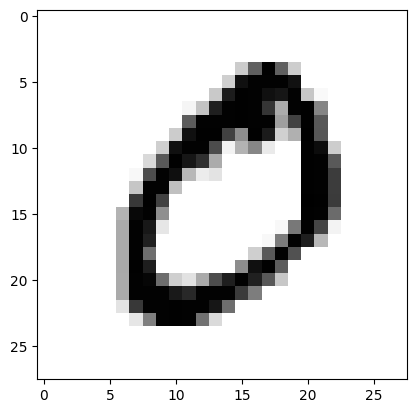

In [ ]:
plt.imshow(digit_image.reshape(28, 28), cmap="binary")

## Training a Binary Classifier

Now that we understand a bit about the structure of our data, let’s move into building a classifier that can recognize whether a given image represents a specific digit or not. This is called binary classification, because there are only two classes: either the sample corresponds to an outcome (positive), or it doesn't. (negative).

To make this a binary classification task, we will create a new version of our label array that is True when the digit matches our target and False otherwise. This way, we can specifically train a model to answer the question: does the image show the chosen digit?

In [ ]:
digit_mask_y_train = (y_train == digit_str)
digit_mask_y_test = (y_test == digit_str)

It helps to check the shape of our new arrays. Let's confirm that the binary label arrays still have the same number of entries as our original training and test sets.

In [ ]:
digit_mask_y_train.shape, digit_mask_y_test.shape

((60000,), (10000,))

Training - or fitting - the model means we are using training sample images and their labels to tune the model’s internal parameters so it can correctly identify digits.

In [ ]:
sgd_clf = linear_model.SGDClassifier(random_state=seed)
sgd_clf.fit(X_train, digit_mask_y_train)

SGDClassifier(random_state=42)

Now we will train a stochastic gradient descent classifier to recognize the chosen digit. The model learns to assign a score to each image, predicting True for the target digit and False for all others.

Once trained, our model can look at new images and make its best guess about which digit is shown.

Let's make a prediction for the digit image we examined earlier. The output tells us whether the model sees this image as the target digit.

In [ ]:
sgd_clf.predict([X_train[digit_index]])

array([ True])

## Measuring Accuracy Using Cross-Validation

Before we continue with classification, we will learn about a new way to measure how well our model performs: cross-validation. When we train a model, we want to know how well it will work on new data that it has never seen before. If we only test on the same data we used for training, we might get an overly optimistic result, because the model has already seen those examples.

Cross-validation helps us get a more realistic estimate of our model's performance without yet relying on the test set. The idea is to split our training data into several smaller groups, called *folds*. We train the model on all but one fold and test it on the remaining fold. We repeat this process so that each fold gets a turn as the test fold. At the end, we average the results to get a better sense of how well our model is likely to perform on new data.

Let's use scikit-learn's `cross_val_score` function to do this for our classifier.

In [ ]:
model_selection.cross_val_score(
    sgd_clf,
    X_train,
    digit_mask_y_train,
    cv=5,
    scoring="accuracy"
)

array([0.98925   , 0.98825   , 0.989     , 0.98725   , 0.98858333])

Here, we are using 5-fold cross-validation (as specified by the `cv=5` argument), meaning the training data is split into 5 folds. The model is trained on 4 folds and tested on the 5th, and this is repeated so each fold is used as a test fold once. The output will be five accuracy scores, one for each fold.

Importantly, we have not had to use our actual test set yet, so we can decide to go back and revise our classifier(s) based on cross-validation performance, without our decisions being biased by the test set.

These accuracy scores appear to be very good - let's compare them to a baseline to see if we're being overly optimistic.

### Comparing to a Baseline

It is often helpful to compare a model to a simple baseline to see if it is actually learning something useful. A common baseline is a "dummy" classifier that always predicts the most frequent class. In our case, that means simply guessing that the digit is not the target digit.

Let's fit a dummy classifier and see how it performs.

In [ ]:
dummy_clf = dummy.DummyClassifier()
dummy_clf.fit(X_train, digit_mask_y_train)

DummyClassifier()

This classifier does not look at the data at all; it just predicts the most common label. By comparing our model's accuracy to the dummy classifier's accuracy, we can see if our model is doing better than guessing.

In [ ]:
model_selection.cross_val_score(
    dummy_clf,
    X_train,
    digit_mask_y_train,
    cv=5,
    scoring="accuracy"
)

array([0.90133333, 0.90133333, 0.90125   , 0.90125   , 0.90125   ])

As we can see, even a dummy classifier gets it right about 90% of the time. Considering that there are 10 digits and our only classes are positive (which accounts for 1 digit, or 10% of the labels) versus negative (which accounts for the other 9 digits, or 90% of the labels), this outcome makes sense.

It also means our previous accuracy score with the SGD classifier was not as good as it initially seemed.

## Confusion Matrix

Let's take a closer look at the types of mistakes our classifier makes. Instead of just checking whether predictions are correct or incorrect, we can use a confusion matrix to see exactly which digits are confused for which other digits.

In [ ]:
y_train_pred = model_selection.cross_val_predict(
    sgd_clf,
    X_train,
    digit_mask_y_train,
    cv=5
)

In [ ]:
cm = metrics.confusion_matrix(digit_mask_y_train, y_train_pred)
cm

array([[53729,   348],
       [  344,  5579]])

As we will see, the confusion matrix is especially useful when working with multiple classes, as it provides a detailed breakdown of performance for each class and allows us to identify specific areas where the model could be improved and to better interpret the results of our classification task.

We can make the confusion matrix more visually pleasing and easier to understand using `ConfusionMatrixDisplay`.

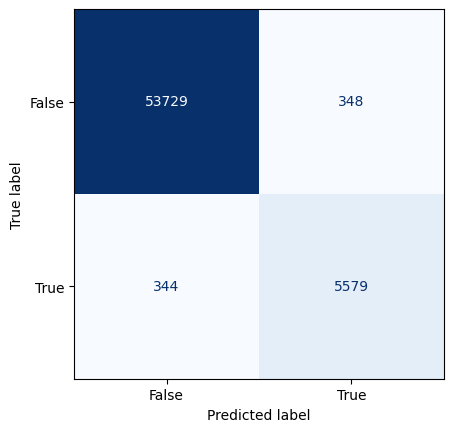

In [ ]:
metrics.ConfusionMatrixDisplay.from_predictions(
    digit_mask_y_train,
    y_train_pred,
    cmap="Blues",
    colorbar=False
)

The confusion matrix for our classifier compares the true labels against the predicted labels. The top-left value shows true negatives (images that are not the digit, correctly identified as such), the bottom-right shows true positives (the digit, correctly identified), and the off-diagonal values show misclassifications. Looking at these values helps us see both the quantity and types of errors. If we notice one type of error is much more common, we might want to tune our model or gather more training data to address it.

## Precision and Recall

Precision tells us, out of all the images our model predicted as the target digit, how many were actually correct. In other words, it measures how reliable our positive predictions are. High precision means that when the model says an image is the target digit, it is usually right, which is especially important when the cost of a false positive is high.

In [ ]:
metrics.precision_score(digit_mask_y_train, y_train_pred)

0.9412856419773916

Recall tells us, out of all the images that truly are the target digit, how many our model correctly identified. High recall means the model is good at finding all the positive cases, even if it sometimes makes mistakes by including some negatives, which is important when missing a positive case would be costly.

In [ ]:
metrics.recall_score(digit_mask_y_train, y_train_pred)

0.941921323653554

The F1 score combines precision and recall into a single number by taking their harmonic mean. This score is useful when we want a balance between precision and recall, especially if we care equally about avoiding false positives and false negatives. A high F1 score means the model does well on both metrics.

In [ ]:
metrics.f1_score(digit_mask_y_train, y_train_pred)

0.9416033755274261

## Training a Multiclass Classifier

Now let's train our classifier to recognize all digits, not just the one we selected earlier. This turns our task from binary classification into multiclass classification, where the model must choose among all possible digit labels.

The only change to the fitting of this SGD classifier is that we are now using the original set of training labels, rather than the "mask" of true/false values with the binary classifier.

**Note: This step may take a few minutes.** To speed it up, you can fit to a slice of the training data (using Python slicing), at the cost of a reduced model; just be sure to slice the features and labels by the same number of samples.

In [ ]:
sgd_clf = linear_model.SGDClassifier(random_state=seed)
sgd_clf.fit(X_train, y_train)

SGDClassifier(random_state=42)

In [ ]:
sgd_clf.predict([X_train[digit_index]])

array(['0'], dtype='<U1')

Here we use our trained classifier to predict the label of a specific digit image from the training set. The output shows which digit the model thinks is present in the image.

The cell below calculates the raw decision (or confidence) scores for each possible digit label, for the image at the chosen index. The decision function returns one confidence score per class, with the highest-scoring label being the digit that the classifier selects as its prediction.

By examining these confidence scores, we can get a sense of how close the competition was between different predictions and how strongly the model preferred the final choice.

In [ ]:
decisions = sgd_clf.decision_function([X_train[digit_index]])
decisions

array([[ 14390.59839396, -36919.31719967,  -9811.47434817,
         -8054.56345089, -21825.25725463, -11313.62371972,
        -23649.39025808, -15986.78463914,  -3798.52944589,
        -10635.46503726]])

For readability, here are the same scores as a Pandas Series, with each index also serving as the digit (from 0 to 9) to which the confidence score refers.

In [ ]:
pd.Series(decisions[0], name="confidence")

,confidence
0,14390.598394
1,-36919.317200
2,-9811.474348
3,-8054.563451
4,-21825.257255
5,-11313.623720
6,-23649.390258
7,-15986.784639
8,-3798.529446
9,-10635.465037


Below, we make an actual prediction, which aligns with the highest confidence score above.

In [ ]:
sgd_clf.predict([X_train[digit_index]])

array(['0'], dtype='<U1')

Now let's run our model on the test set and display a confusion matrix to show where it made the most mistakes.

In [ ]:
y_pred = sgd_clf.predict(X_test)

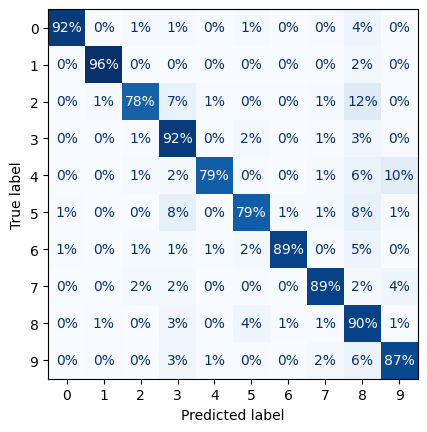

In [ ]:
metrics.ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    normalize="true",
    values_format=".0%",
    cmap="Blues",
    colorbar=False
)

The above confusion matrix is expressed in terms of percentages (as the counts would be large numbers and thus difficult to read here).

We can see that some of the biggest mix-ups included the model mistaking 2s for 8s and 4s for 9s.

## What's Next?

You are encouraged to explore other classifiers in scikit-learn. Since they have common interfaces, you can usually just swap out a previous model constructor (e.g. `linear_model.SGDClassifier`) with a new one, such as [`svm.SVC`](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html) or [`ensemble.RandomForestClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html); we will be discussing these methods in later modules. If you come across a promising approach, please do share it in this module's discussion forum.

As part of this module, you will next be asked to complete a similar forthcoming Notebook on your own, using much of the same functions as we saw here.